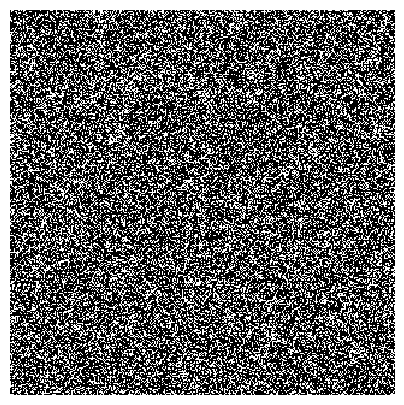

Sampled pixels: 33649
Total pixels: 102400
Fraction sampled: 0.328603515625
Acceleration factor R: 3.0431810752176887


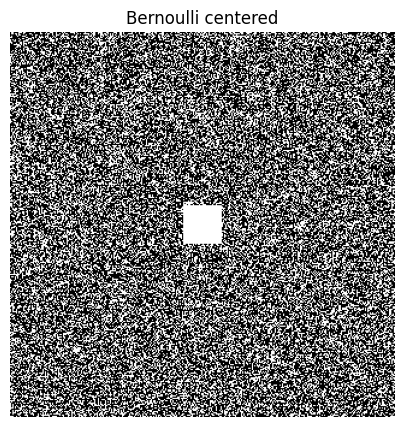

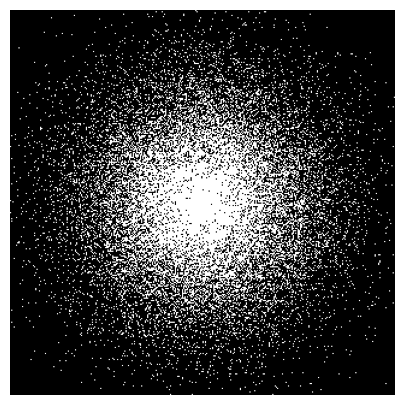

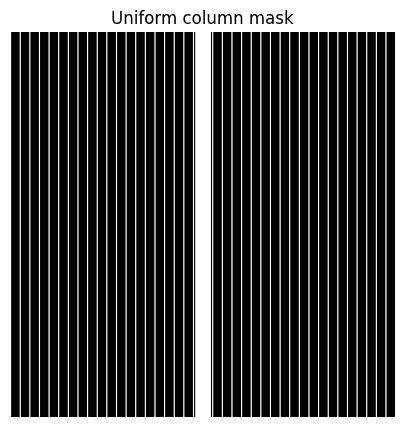

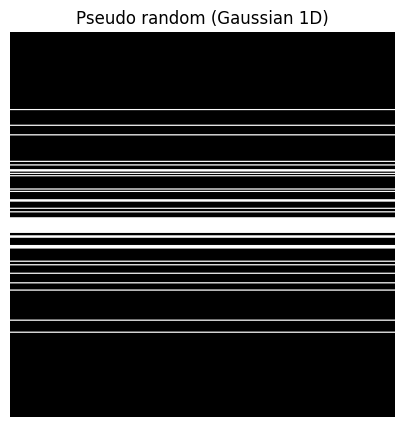

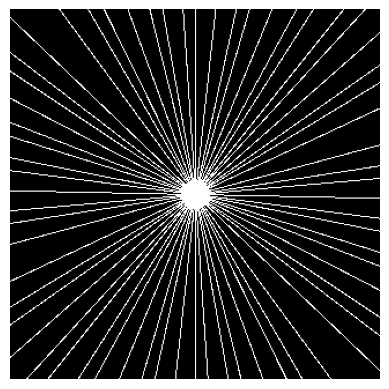

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from utilities.masks import (
    BernoulliMask,
    CenteredBernoulliMask,
    Gaussian1DColumnMask,
    Gaussian1DRowMask,
    VariableDensityMask,
    RadialMask,
    UniformColumnMask
)

bernoulli_mask = BernoulliMask(0.33, seed=42).generate((320,320))

# bernoulli
plt.figure(figsize=(5, 5))
plt.imshow(bernoulli_mask, cmap='gray', vmin=0, vmax=1, interpolation='nearest') # interpolation='nearest'
#plt.title('Bernoulli Mask')
plt.axis('off')
plt.show()

print('Sampled pixels:', np.sum(bernoulli_mask))
print('Total pixels:', bernoulli_mask.size)
print('Fraction sampled:', np.sum(bernoulli_mask) / bernoulli_mask.size)
print('Acceleration factor R:', bernoulli_mask.size / np.sum(bernoulli_mask))

# centered bernoulli
centered_bernoulli_mask = CenteredBernoulliMask(0.4, 0.1, seed=42).generate((320,320))

plt.figure(figsize=(5, 5))
plt.imshow(centered_bernoulli_mask, cmap='gray', vmin=0, vmax=1)
plt.title('Bernoulli centered')
plt.axis('off')
plt.show()

# variable density (gaussian, exponential)
variable_density_mask = VariableDensityMask('gaussian', 0.25, seed=42).generate((320,320))

plt.figure(figsize=(5, 5))
plt.imshow(variable_density_mask, cmap='gray', vmin=0, vmax=1)
#plt.title('Variable density(Gaussian 2D)')
plt.axis('off')
plt.show()

# uniform column
uniform_col = UniformColumnMask((320,320), 8, seed=42).get_mask()

plt.figure(figsize=(5, 5))
plt.imshow(uniform_col, cmap='gray', vmin=0, vmax=1)
plt.title('Uniform column mask')
plt.axis('off')
plt.show()


# pseudo random column
gauss_1drow = Gaussian1DRowMask((320,320), 8, 6, seed=42).get_mask()

plt.figure(figsize=(5, 5))
plt.imshow(gauss_1drow, cmap='gray', vmin=0, vmax=1)
plt.title('Pseudo random (Gaussian 1D)')
plt.axis('off')
plt.show()

#radial 
radial_mask_array = RadialMask((320,320), 32, 0.08).generate()

plt.imshow(radial_mask_array, cmap='gray')
#plt.title("Radial undersampling mask (20 spokes)")
plt.axis("off")
plt.show()

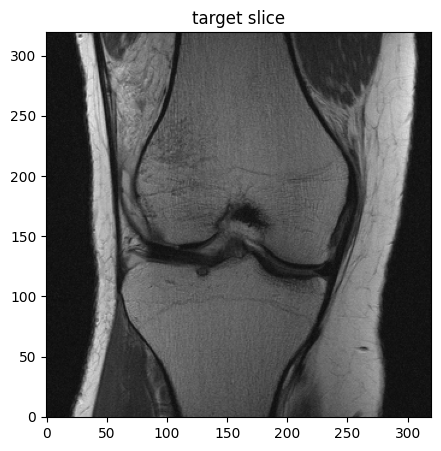

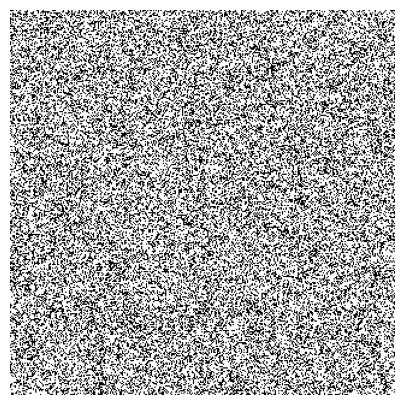

Fraction sampled Bernoulli: 0.6504296875
Acceleration factor R (Bernoulli): 1.5374451984865773


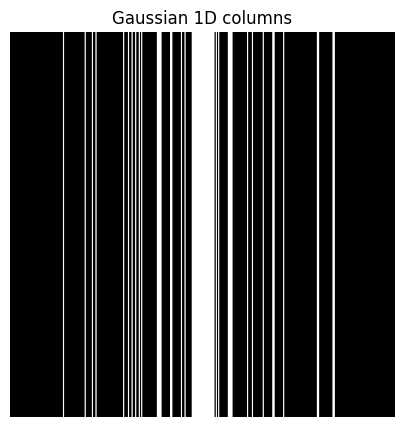

Fraction sampled: 0.165625
Acceleration factor R: 6.037736


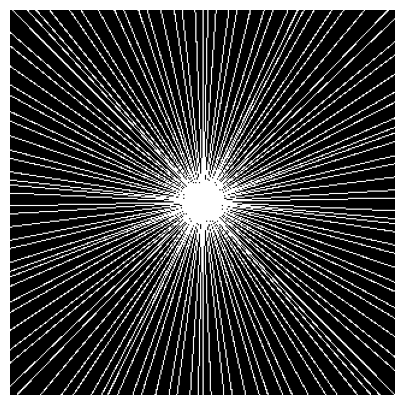

Fraction sampled radial: 0.19902344
Acceleration factor R - radial: 5.0245337


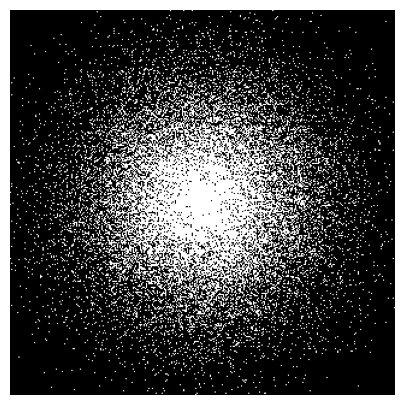

Fraction sampled Gaussian 2D: 0.200849609375
Acceleration factor R Gaussian 2D: 4.978849613458453


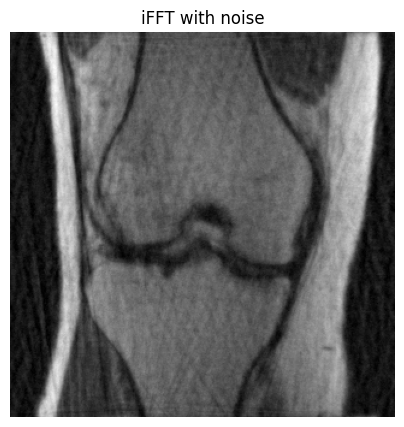

=== Scale diagnostics ===
slice_target:   min=0.0412  max=1.0000  mean=0.3136


In [45]:
# for figure 1.1 in thesis
import numpy as np
import matplotlib.pyplot as plt
import h5py
from utilities.masks import (
    Gaussian1DColumnMask,
    Gaussian1DRowMask,
    SimpleMask,
    BernoulliMask,
    CenteredBernoulliMask,
    SimpleMask2D,
    VariableDensityMask,
    RadialMask,
    UniformColumnMask
)
import matplotlib as mpl
mpl.rcParams['image.origin'] = 'lower'

file_name = r"C:\Users\jatsok003\file1000719.h5"
hf = h5py.File(file_name)

volume_kspace = hf['kspace'][()]
target = hf['reconstruction_rss'][()]

slice_kspace = volume_kspace[15]
slice_target = target[18]  # match slice index to kspace slice
old_target = target[20]

old_target = old_target / old_target.max()
kspace = np.fft.fftshift(np.fft.fft2(slice_target, norm='ortho'))

# noise
# scale by k-space RMS (most principled)
target_snr_db = 20  # e.g. 30-low, 20-mid, 10-heavy (dB SNR)
kspace_rms = np.sqrt(np.mean(np.abs(kspace)**2))
sigma_noise = kspace_rms / (10 ** (target_snr_db / 20))

# Generate complex AWGN (MRI noise is complex Gaussian)
noise = (sigma_noise / np.sqrt(2)) * (
   np.random.randn(*slice_target.shape) + 1j * np.random.randn(*slice_target.shape)
)

# centered_bernoulli_mask = CenteredBernoulliMask(0.4, 0.1, seed=42).generate(slice_target.shape)
# uniform_col = UniformColumnMask((slice_target.shape), 8, seed=42).get_mask()
# simple_mask_columns = SimpleMask(4).mask_columns((320,320))
# simple_mask_rows = SimpleMask(4).mask_rows((320,320))
# simple_mask2d = SimpleMask2D(4,4).get_mask(slice_target.shape)
bernoulli_mask = BernoulliMask(0.65, seed=42).generate(slice_target.shape)
radial_mask = RadialMask((slice_target.shape), 60, 0.01).generate()
gauss1d_col = Gaussian1DColumnMask((slice_target.shape), 6, 4, seed=42).get_mask()
gauss1d_row = Gaussian1DRowMask((slice_target.shape), 6, 4, seed=42).get_mask()
gauss2d_mask = VariableDensityMask('gaussian', 0.254, seed=42).generate(slice_target.shape)

slice_target = slice_target / slice_target.max()

# # full kspace
# plt.figure(figsize=(5, 5))
# plt.imshow(np.abs(kspace), cmap='gray', vmin=0, vmax=1)
# # np.log(1 + np.abs(np.fft.fft2(slice_target)))
# plt.title('full kspace')
# plt.colorbar()
# plt.axis('off')
# plt.show()
# target 
plt.figure(figsize=(5, 5))
plt.imshow(slice_target, cmap='gray', vmin=0, vmax=1)
plt.title('target slice')
#plt.colorbar()
plt.axis('on')
plt.show()

# plt.figure(figsize=(5, 5))
# plt.imshow(old_target, cmap='gray', vmin=0, vmax=1)
# plt.title('target slice 20')
# #plt.colorbar()
# plt.axis('on')
# plt.show()

plt.figure(figsize=(5, 5))
plt.imshow(bernoulli_mask, cmap='gray', vmin=0, vmax=1)
#plt.title('Bernoulli')
plt.axis('off')
plt.show()

print('Fraction sampled Bernoulli:', np.sum(bernoulli_mask) / bernoulli_mask.size)
print('Acceleration factor R (Bernoulli):', bernoulli_mask.size / np.sum(bernoulli_mask))

plt.figure(figsize=(5, 5))
plt.imshow(gauss1d_col, cmap='gray', vmin=0, vmax=1)
plt.title('Gaussian 1D columns')
plt.axis('off')
plt.show()

print('Fraction sampled:', np.sum(gauss1d_col) / gauss1d_col.size)
print('Acceleration factor R:', gauss1d_col.size / np.sum(gauss1d_col))

plt.figure(figsize=(5, 5))
plt.imshow(radial_mask, cmap='gray', vmin=0, vmax=1)
#plt.title('Pseudo random (Gaussian 1D)')
plt.axis('off')
plt.show()
print('Fraction sampled radial:', np.sum(radial_mask) / radial_mask.size)
print('Acceleration factor R - radial:', radial_mask.size / np.sum(radial_mask))

plt.figure(figsize=(5, 5))
plt.imshow(gauss2d_mask, cmap='gray', vmin=0, vmax=1)
#plt.title('Gaussian 2D')
plt.axis('off')
plt.show()

print('Fraction sampled Gaussian 2D:', np.sum(gauss2d_mask) / gauss2d_mask.size)
print('Acceleration factor R Gaussian 2D:', gauss2d_mask.size / np.sum(gauss2d_mask))

y = radial_mask * (kspace + noise)

plt.figure(figsize=(5, 5))
plt.imshow(np.abs(np.fft.ifft2(np.fft.ifftshift(y), norm='ortho')) / np.abs(np.fft.ifft2(np.fft.ifftshift(y), norm='ortho')).max(), cmap='gray', vmin=0, vmax=1)
#np.abs(np.fft.ifft2(np.fft.ifftshift(kspace),norm='ortho'))
# np.abs(np.fft.ifft2(np.fft.ifftshift
plt.title('iFFT with noise')
#plt.colorbar()
plt.axis('off')
plt.show()

print("=== Scale diagnostics ===")
print(f"slice_target:   min={slice_target.min():.4f}  max={slice_target.max():.4f}  mean={slice_target.mean():.4f}")

# print("Max k-space magnitude:", np.abs(kspace).max())
# print("Mean k-space magnitude:", np.abs(kspace).mean())
# print("Noise std:", sigma_noise)
# If sigma_noise > mean k-space magnitude, your SNR is below 1 → pure noise image

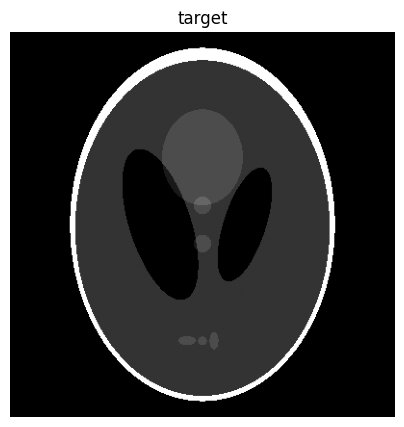

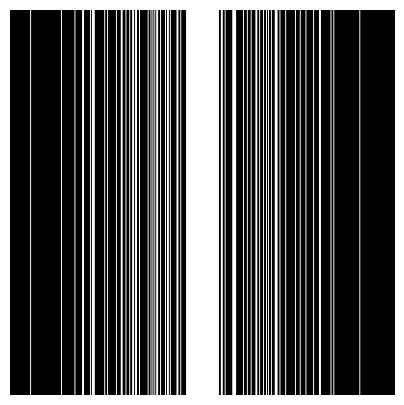

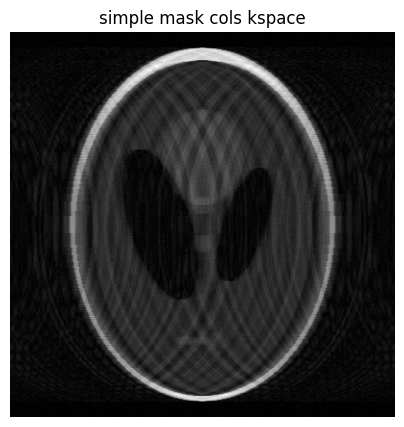

Max k-space magnitude: 49.26357843137256
Mean k-space magnitude: 0.07684329968681045
Noise std: 0.024677511117996778


In [7]:
import skimage as ski
from utilities.masks import (
    VariableDensityMask,
    BernoulliMask,
    Gaussian1DColumnMask
)

shepp_logan = ski.data.shepp_logan_phantom()

kspace = np.fft.fftshift(np.fft.fft2(shepp_logan, norm='ortho'))
variable_density_mask = VariableDensityMask('gaussian', 0.15, seed=42).generate(shepp_logan.shape)
bernoulli_mask = BernoulliMask(0.5, seed=42).generate(shepp_logan.shape)
gauss1d_col = Gaussian1DColumnMask((shepp_logan.shape), 4, 4, seed=42).get_mask()

# noise
# scale by k-space RMS (most principled)
target_snr_db = 20  # e.g. 30-low, 20-mid, 10-heavy (dB SNR)
kspace_rms = np.sqrt(np.mean(np.abs(kspace)**2))
sigma_noise = kspace_rms / (10 ** (target_snr_db / 20))

# Generate complex AWGN (MRI noise is complex Gaussian)
noise = (sigma_noise / np.sqrt(2)) * (
   np.random.randn(*shepp_logan.shape) + 1j * np.random.randn(*shepp_logan.shape)
)

y = gauss1d_col * (kspace + noise)

# target 
plt.figure(figsize=(5, 5))
plt.imshow(shepp_logan / shepp_logan.max(), cmap='gray', vmin=0, vmax=1)
plt.title('target')
#plt.colorbar()
plt.axis('off')
plt.show()

plt.figure(figsize=(5, 5))
plt.imshow(gauss1d_col, cmap='gray', vmin=0, vmax=1)
#plt.title('Pseudo random (Gaussian 1D)')
plt.axis('off')
plt.show()

plt.figure(figsize=(5, 5))
plt.imshow(np.abs(np.fft.ifft2(np.fft.ifftshift(y), norm='ortho')) / np.abs(np.fft.ifft2(np.fft.ifftshift(y), norm='ortho')).max(), cmap='gray', vmin=0, vmax=1)
#np.abs(np.fft.ifft2(np.fft.ifftshift(kspace),norm='ortho'))
plt.title('simple mask cols kspace')
#plt.colorbar()
plt.axis('off')
plt.show()

print("Max k-space magnitude:", np.abs(kspace).max())
print("Mean k-space magnitude:", np.abs(kspace).mean())
print("Noise std:", sigma_noise)

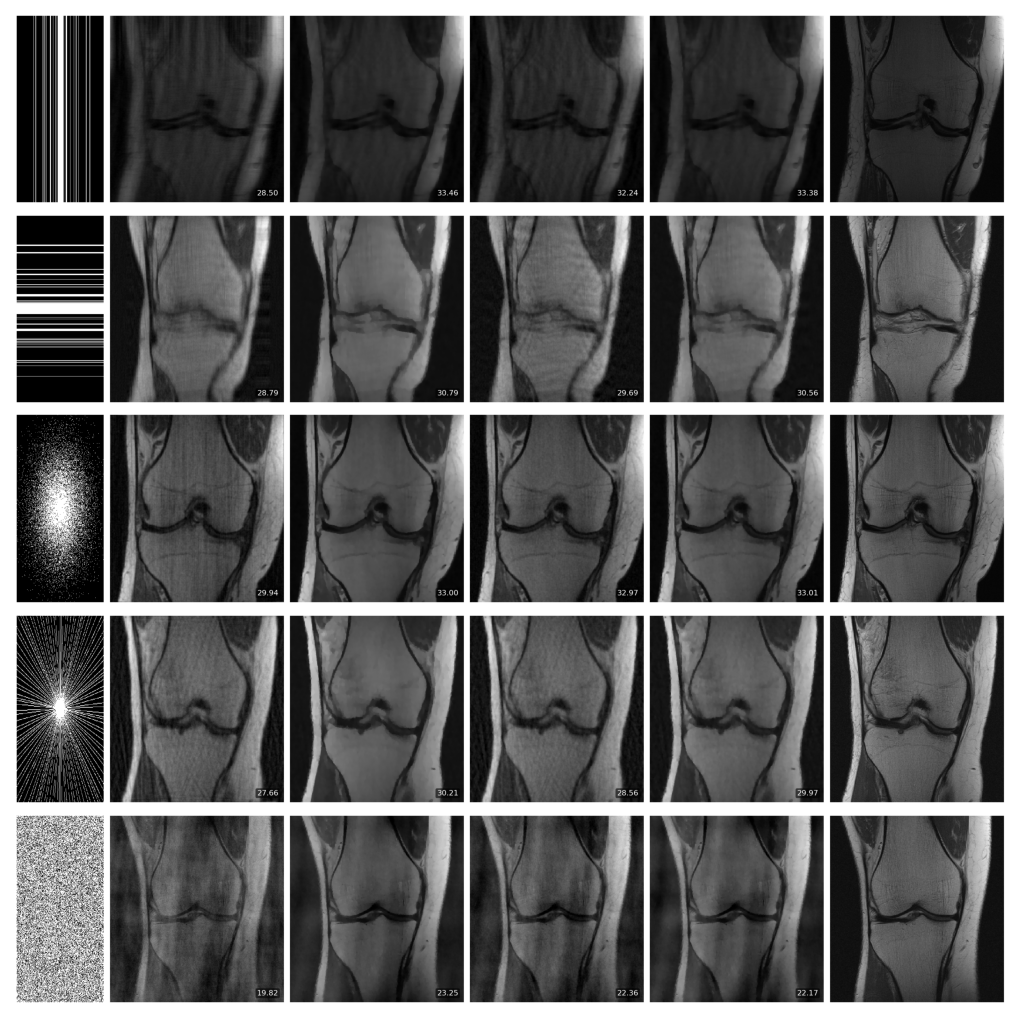

In [46]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib as mpl
#mpl.rcParams['image.origin'] = 'lower'

# paths to your images
images = [
    r"C:\Users\jatsok003\Bach figures\1dgauss_col.png",
    r"C:\Users\jatsok003\Bach figures\1dgauss_row.png",
    r"C:\Users\jatsok003\Bach figures\2dgauss.png",
    r"C:\Users\jatsok003\Bach figures\radial.png",
    r"C:\Users\jatsok003\Bach figures\random.png"
]

# version 1 

fig, axes = plt.subplots(len(images), 1, figsize=(10, 10))

for ax, img_path in zip(axes, images):
    img = mpimg.imread(img_path)
    img = np.flipud(img)
    ax.imshow(img, aspect="auto")
    ax.axis("off")

#plt.tight_layout()
fig.subplots_adjust(hspace=0, left=0, right=1, top=1, bottom=0) # hspace=0, left=0, right=1, top=1, bottom=0
plt.savefig("combined_results.png", dpi=300, bbox_inches="tight")
plt.show()

# version 2

# fig, axes = plt.subplots(len(images), 1, figsize=(10, 12))

# for ax, img_path in zip(axes, images):
#     ax.imshow(mpimg.imread(img_path))
#     ax.set_xticks([])
#     ax.set_yticks([])
#     ax.set_frame_on(False)

# plt.subplots_adjust(hspace=0.02)
# plt.savefig("combined_results.png", dpi=300, bbox_inches="tight", pad_inches=0)